In [4]:
import pandas as pd

df = pd.read_csv("gig_worker_credit_data_v2.csv")
df.head()
print(df.head())

         worker_type  monthly_income  income_stability  customer_rating  \
0  Ride Share Driver           40491                 6              4.9   
1    Content Creator          141410                 7              4.6   
2         Freelancer           16750                 6              4.5   
3  Ride Share Driver           25319                 5              4.9   
4   Delivery Partner           39771                 8              4.6   

   savings_ratio  upi_transactions  bill_payment_score  emi_defaults  \
0           0.32               420                  64             4   
1           0.14               188                  99             3   
2           0.35               329                  85             5   
3           0.37                63                  57             3   
4           0.35               117                  64             3   

   spending_volatility  employment_duration  existing_debt_ratio  \
0                    1                   41     

In [5]:
from sklearn.preprocessing import LabelEncoder

worker_encoder = LabelEncoder()
risk_encoder = LabelEncoder()

df["worker_type"] = worker_encoder.fit_transform(df["worker_type"])

df["risk_category"] = risk_encoder.fit_transform(df["risk_category"])
df.head()

,worker_type,monthly_income,income_stability,customer_rating,savings_ratio,upi_transactions,bill_payment_score,emi_defaults,spending_volatility,employment_duration,existing_debt_ratio,platform_dependency,emergency_fund_months,financial_health_score,risk_category
0,3,40491,6,4.9,0.32,420,64,4,1,41,0.44,31,7,59,2
1,0,141410,7,4.6,0.14,188,99,3,8,23,0.27,93,11,87,1
2,2,16750,6,4.5,0.35,329,85,5,10,7,0.77,39,1,40,0
3,3,25319,5,4.9,0.37,63,57,3,4,56,0.44,69,4,57,2
4,1,39771,8,4.6,0.35,117,64,3,3,23,0.05,55,5,77,1


In [6]:
from sklearn.model_selection import train_test_split

X = df.drop(
    ["risk_category", "financial_health_score"],
    axis=1
)

y = df["risk_category"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(800, 13)
(200, 13)


In [7]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [8]:
y_pred = rf_model.predict(X_test)

print(y_pred[:10])

[2 2 2 2 2 1 2 2 1 2]


In [9]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Accuracy:")
print(accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy:
0.79

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.50      0.67        40
           1       0.95      0.65      0.77        57
           2       0.72      0.98      0.83       103

    accuracy                           0.79       200
   macro avg       0.89      0.71      0.76       200
weighted avg       0.84      0.79      0.78       200


Confusion Matrix:
[[ 20   0  20]
 [  0  37  20]
 [  0   2 101]]


In [10]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df)

                  Feature  Importance
10    existing_debt_ratio    0.193999
7            emi_defaults    0.145715
6      bill_payment_score    0.122621
12  emergency_fund_months    0.111537
4           savings_ratio    0.088310
1          monthly_income    0.057798
5        upi_transactions    0.057327
11    platform_dependency    0.050661
9     employment_duration    0.046989
3         customer_rating    0.042945
8     spending_volatility    0.034495
2        income_stability    0.029066
0             worker_type    0.018536


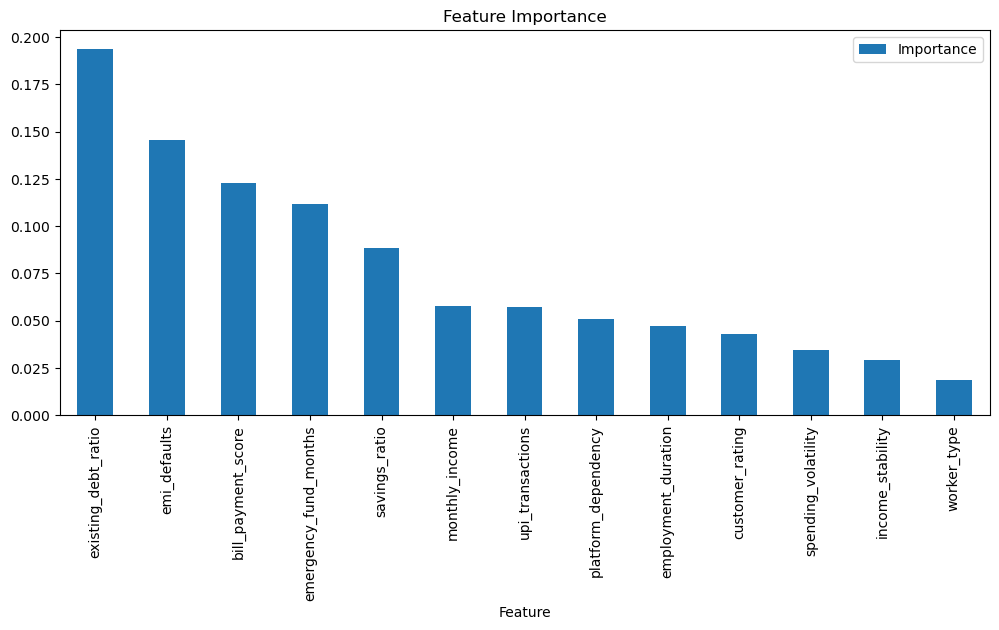

In [11]:
import matplotlib.pyplot as plt

importance_df.plot(
    x="Feature",
    y="Importance",
    kind="bar",
    figsize=(12,5)
)

plt.title("Feature Importance")
plt.show()

In [12]:
print(risk_encoder.classes_)

['High Risk' 'Low Risk' 'Moderate Risk']


In [1]:
from xgboost import XGBClassifier

In [3]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    random_state=42
)

xgb_model.fit(x_train, y_train)

print("XGBoost Model Trained Successfully")

NameError: name 'x_train' is not defined

In [5]:
import pandas as pd

df = pd.read_csv("gig_worker_credit_data_v2.csv")
df.head()
print(df.head())

         worker_type  monthly_income  income_stability  customer_rating  \
0  Ride Share Driver           40491                 6              4.9   
1    Content Creator          141410                 7              4.6   
2         Freelancer           16750                 6              4.5   
3  Ride Share Driver           25319                 5              4.9   
4   Delivery Partner           39771                 8              4.6   

   savings_ratio  upi_transactions  bill_payment_score  emi_defaults  \
0           0.32               420                  64             4   
1           0.14               188                  99             3   
2           0.35               329                  85             5   
3           0.37                63                  57             3   
4           0.35               117                  64             3   

   spending_volatility  employment_duration  existing_debt_ratio  \
0                    1                   41     

In [6]:
from sklearn.preprocessing import LabelEncoder

worker_encoder = LabelEncoder()
risk_encoder = LabelEncoder()

df["worker_type"] = worker_encoder.fit_transform(df["worker_type"])
df["risk_category"] = risk_encoder.fit_transform(df["risk_category"])
df.head()

,worker_type,monthly_income,income_stability,customer_rating,savings_ratio,upi_transactions,bill_payment_score,emi_defaults,spending_volatility,employment_duration,existing_debt_ratio,platform_dependency,emergency_fund_months,financial_health_score,risk_category
0,3,40491,6,4.9,0.32,420,64,4,1,41,0.44,31,7,59,2
1,0,141410,7,4.6,0.14,188,99,3,8,23,0.27,93,11,87,1
2,2,16750,6,4.5,0.35,329,85,5,10,7,0.77,39,1,40,0
3,3,25319,5,4.9,0.37,63,57,3,4,56,0.44,69,4,57,2
4,1,39771,8,4.6,0.35,117,64,3,3,23,0.05,55,5,77,1


In [8]:
X = df.drop(
    ["risk_category", "financial_health_score"],
    axis=1
)

y = df["risk_category"]

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(800, 13)
(200, 13)


In [10]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    random_state=42
)

xgb_model.fit(X_train, y_train)

print("XGBoost Model Trained Successfully")

XGBoost Model Trained Successfully


In [11]:
y_pred_xgb = xgb_model.predict(X_test)

print(y_pred_xgb[:10])

[2 2 2 2 1 1 2 2 1 1]


In [12]:
from sklearn.metrics import accuracy_score

print("Accuracy:")
print(accuracy_score(y_test, y_pred_xgb))

Accuracy:
0.81


In [13]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.89      0.60      0.72        40
           1       0.91      0.74      0.82        57
           2       0.76      0.93      0.83       103

    accuracy                           0.81       200
   macro avg       0.85      0.76      0.79       200
weighted avg       0.83      0.81      0.81       200



In [14]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred_xgb))

[[24  0 16]
 [ 0 42 15]
 [ 3  4 96]]


In [15]:
import pandas as pd

importance_df_xgb = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})

importance_df_xgb = importance_df_xgb.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df_xgb)

                  Feature  Importance
7            emi_defaults    0.228351
10    existing_debt_ratio    0.172304
12  emergency_fund_months    0.125003
6      bill_payment_score    0.115002
4           savings_ratio    0.089166
0             worker_type    0.039885
11    platform_dependency    0.034394
1          monthly_income    0.034356
8     spending_volatility    0.034207
5        upi_transactions    0.034187
3         customer_rating    0.034015
9     employment_duration    0.031188
2        income_stability    0.027943


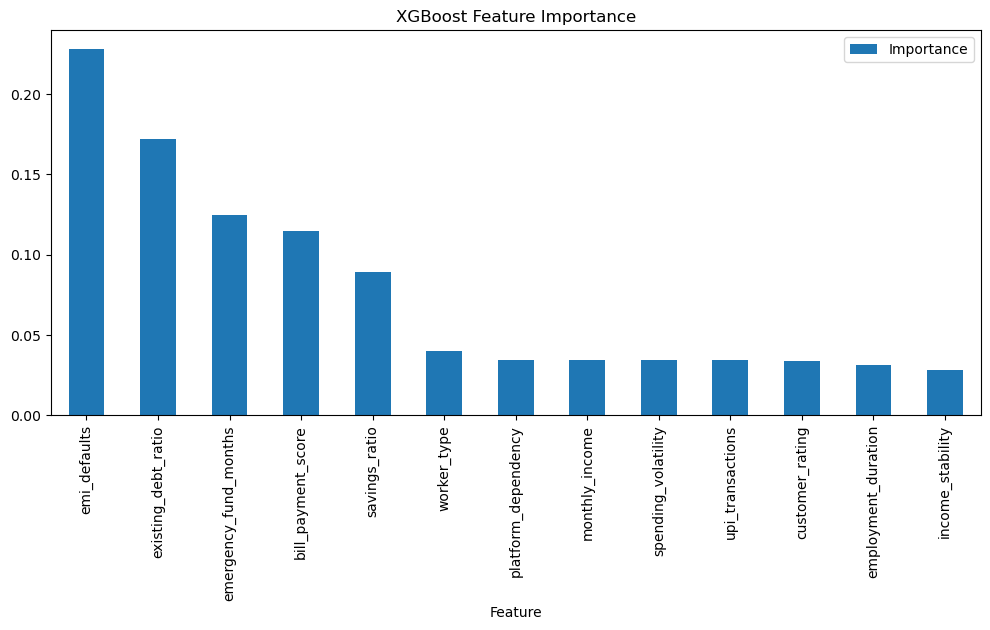

In [16]:
import matplotlib.pyplot as plt

importance_df_xgb.plot(
    x="Feature",
    y="Importance",
    kind="bar",
    figsize=(12,5)
)

plt.title("XGBoost Feature Importance")
plt.show()